In [1]:
# ============================================================
# Notebook setup
# ============================================================
%load_ext autoreload
%autoreload 2

# Retrain or use existing models
use_cached_weights=True

# Control figure size
figsize=(14, 3.5)
figsize_narrow=(14, 2.5)

import numpy as np
from util import util
import warnings
warnings.filterwarnings("ignore", ".*Consider increasing the value of the `num_workers` argument.*")
warnings.filterwarnings("ignore", ".*GPU available but not used.*")
warnings.filterwarnings("ignore", ".*Previous log files in this directory will be deleted when the new ones are saved!.*")
warnings.filterwarnings("ignore", ".*Checkpoint directory.*exists and is not empty.*")

# Problem construction
seed, nitems = 42, 20
rel_req = 0.6
rel_buffer_cost = 10
data_tr = util.generate_costs(nsamples=350, nitems=nitems, seed=seed, noise_scale=.2, noise_type='rayleigh', noise_scale_type='relative')
prb = util.generate_2s_problem(nitems, requirement=rel_req * data_tr.mean().sum(), rel_buffer_cost=rel_buffer_cost, seed=seed)
data_ts = util.generate_costs(nsamples=150, nitems=nitems, seed=seed, sampling_seed=seed+1, noise_scale=0.2, noise_type='rayleigh', noise_scale_type='relative', nsamples_per_point=30)

# Retrieve the previous PFL and SFGE models
pfl = util.TwoPhaseModel(input_size=1, output_size=nitems, hidden_sizes=[], name='pfl_2s')
pfl, history, metadata = util.train_ml_model(pfl, data_tr.index.values.reshape(-1, 1), data_tr.values, epochs=1500, load_cached=use_cached_weights, enable_progress_bar=False, accelerator='cpu')

sfge = util.DFLModel(input_size=1, output_size=nitems, hidden_sizes=[], problem=prb, name='sfge_2s', dfl_method='sfge_2s', dfl_params={'sigma': 0.1}, warm_start_state_dict=pfl.state_dict(), lr=1e-3, drop_cache_at_end=False)
sfge, history, metadata = util.train_ml_model(sfge, data_tr.index.values.reshape(-1, 1), data_tr.values, epochs=50, load_cached=use_cached_weights, enable_progress_bar=False, accelerator='cpu', batch_size=32)

pfl_nl = util.TwoPhaseModel(input_size=1, output_size=nitems, hidden_sizes=[16], name='pfl_2s_nl')
pfl_nl, history, metadata = util.train_ml_model(pfl_nl, data_tr.index.values.reshape(-1, 1), data_tr.values, epochs=1500, load_cached=use_cached_weights, enable_progress_bar=False, accelerator='cpu')

sfge_nl = util.DFLModel(input_size=1, output_size=nitems, hidden_sizes=[16], problem=prb, name='sfge_2s_nl', dfl_method='sfge_2s', dfl_params={'initial_sigma': 0.1}, warm_start_state_dict=pfl_nl.state_dict(), lr=1e-4)
sfge_nl, history, metadata = util.train_ml_model(sfge_nl, data_tr.index.values.reshape(-1, 1), data_tr.values, epochs=100, load_cached=use_cached_weights, enable_progress_bar=False, accelerator='cpu', batch_size=32)

# BB Differentiation via Importance Sampling

## Dusting Off Some Old Tools

**SFGE is not the only technique to take advantage of stochastic smoothing**

Let's start again from the smoothed regret definition:

$$
\tilde{L}_{DFL}(\theta) = \mathbb{E}_{(x, y) \sim P(X, Y), \tilde{y} \sim P(\tilde{Y}; \theta)}[\text{regret}(y, \tilde{y})]
$$

where $P_\hat{y}(\tilde{Y}; \theta) = \mathcal{N}(h(x; \theta))$, for sake of brevity

**Let's assume we got our samples from _a different distribution_ instead**

In other words, we have that $\tilde{y} \sim Q(\tilde{Y})$

* We will consider how we can estimate the above expectation
* ...Based on the "wrong" samples we have

> **This is actually a problem we have already encountered!**

## Bridging Distributions via Importance Sampling

**With our samples we can directly estimate:**

$$
\mathbb{E}_{(x, y) \sim P(X, Y), \tilde{y} \sim Q(\tilde{Y})}[g(\tilde{y}; \theta)]
$$

with:

$$
g(\tilde{y}; \theta) = \frac{p_P(\tilde{y}; \theta)}{p_Q(\tilde{y})} \text{regret}(y, \tilde{y})
$$

By combining the two together we get:

$$
\mathbb{E}_{(x, y) \sim P(X, Y), \tilde{y} \sim Q(\tilde{Y})}\left[ \frac{p_P(\tilde{y}; \theta)}{p_Q(\tilde{y})} \text{regret}(y, \tilde{y}) \right]
$$

## Bridging Distributions via Importance Sampling

**By expanding the expectation we get:**

$$\begin{align}
\mathbb{E}_{(x, y) \sim P(X, Y), \tilde{y} \sim Q(\tilde{Y})}\left[ \frac{p_P(\tilde{y}; \theta)}{p_Q(\tilde{y})} \text{regret}(y, \tilde{y}) \right] & = \\
\mathbb{E}_{(x, y) \sim P(X, Y)}\left[\int_{\tilde{y}} p_Q(\tilde{y}) \frac{p_P(\tilde{y}; \theta)}{p_Q(\tilde{y})} \text{regret}(y, \tilde{y}) \, d\tilde{y} \right] & = \\
\mathbb{E}_{(x, y) \sim P(X, Y), \tilde{y} \sim P(\tilde{Y}; \theta)}\left[\text{regret}(y, \tilde{y}) \right]
\end{align}$$

Which means that:

* The first expectaction, with the _importance weights_ $p_P / p_Q$
* ...Is an estimator for the quantity we are interested in

This is a classical application of _importance sampling_

## Differentiation via Importance Sampling

**This is interesting since we can use it to _obtain a gradient_**

* Given a training example $(x, y)$
* Let's assume we get access to $N$ samples $\tilde{y}_k$ from $Q(\tilde{Y})$

Then we have that:

$$
\mathbb{E}_{\tilde{y} \sim Q(\tilde{Y})}\left[ \frac{p_P(\tilde{y}; \theta)}{p_Q(\tilde{y})} \text{regret}(y, \tilde{y}) \right] \simeq \frac{1}{N} \sum_{k=1}^N \frac{p_P(\tilde{y}; \theta)}{p_Q(\tilde{y})} \text{regret}(y, \tilde{y})
$$

where:

* The probability $p_Q(\tilde{y})$ is _fixed_ and known (we can choose it!)
* The probability $p_P(\tilde{y}; \theta)$ depends on $\theta$ and _can be differentiated_

## Differentiation via Importance Sampling

**Overall, at every gradient step:**

_1)_ We draw samples according to sampling distribution $Q(\tilde{Y})$:

* For example, we can use $\mathcal{N}(\hat{y}, \sigma')$
* In our implementation, we will have $\sigma' = \sigma \rho$, with $\rho > 1$

_2)_ We compute the loss function:

$$
\frac{1}{N} \sum_{k=1}^N \frac{p_P(\tilde{y}; \theta)}{p_Q(\tilde{y})} \text{regret}(y, \tilde{y})
$$

* As in the SFGE case, it makes sense to use a baseline and compute _advantage_
* In our implementation, we will do it by standardizing the regret over the mini-batches

## Basic IS Policy Gradient

**The result is a basic blck-box DFL method based on IS**

...Which relies on ideas from RL and multi-armed bandits problems

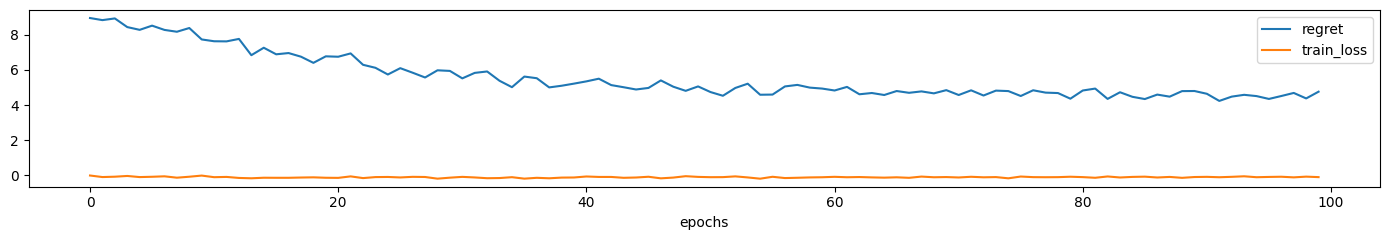

training time: 34.8687
R2: 0.711, MAE: 0.085, RMSE: 0.103 (training)
R2: 0.804, MAE: 0.063, RMSE: 0.078 (test)


In [2]:
bonis_nl = util.DFLModel(input_size=1, output_size=nitems, hidden_sizes=[16], problem=prb, name='bonis_2s', dfl_method='bonis_2s', dfl_params={'sigma': 0.1, 'sigma_multiplier': 1.1}, warm_start_state_dict=pfl_nl.state_dict(), lr=1e-4, drop_cache_at_end=False)
bonis_nl, history, metadata_bonis = util.train_ml_model(bonis_nl, data_tr.index.values.reshape(-1, 1), data_tr.values, epochs=100, load_cached=use_cached_weights, enable_progress_bar=False, accelerator='cpu', batch_size=32)
util.plot_training_history(history, metadata=metadata_bonis, figsize=figsize_narrow, print_scores=False)
util.print_ml_metrics(bonis_nl, data_tr.index.values.reshape(-1, 1), data_tr.values, label='training')
util.print_ml_metrics(bonis_nl, data_ts.index.values.reshape(-1, 1), data_ts.values, label='test')

## Basic IS Policy Gradient

**In terms of performance, it is comparable with the SFGE approach**

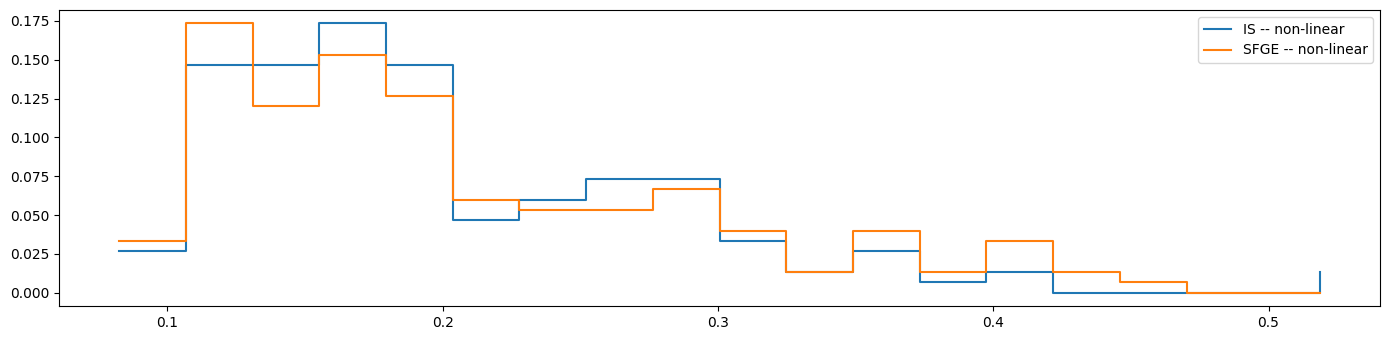

Mean: 0.203 (IS -- non-linear), 0.208 (SFGE -- non-linear)


In [3]:
bonis_nl_evpf = util.compute_evpf_2s(prb, bonis_nl, data_ts, tlim=10)
sfge_nl_evpf = util.compute_evpf_2s(prb, sfge_nl, data_ts, tlim=10)
util.plot_histogram(bonis_nl_evpf, figsize=figsize, label='IS -- non-linear', data2=sfge_nl_evpf, label2='SFGE -- non-linear', print_mean=True);

The two approaches are actually combined in some algorithms

## Recycling Samples

**We can use IS to _reduce our reliance on sampling_**

For the _smoothing distribution_, the can make usual choice:

$$
P(\tilde{Y}; \theta) = \mathcal{N}(h(x; \theta), \sigma)
$$

For the _sample and its distribution_, we use:

$$
\tilde{y} \sim Q(\tilde{Y}) = \mathcal{N}(\hat{y}, \sigma)
$$

* Where $\tilde{y}$ is the last evaluated sample
* ...And $\hat{y}$ is the prediction for its smoothing distribution

> **In practice, we can _reuse past samples_**<br>
> Which is a big deal, since sampling requires solving optimization problems

## ...Until they are Stale

**How much can we push this on?**

Let's consider the variance of our IS-based estimator:

$$
\text{Var}_{\tilde{y} \sim Q(\tilde{Y})}\left( \frac{p_P(\tilde{y}; \theta)}{p_Q(\tilde{y})} \text{regret}(y, \tilde{y}) \right)
$$

By basic propertis of variance, we can expand it as:

$$
\mathrm{E}_{\tilde{y} \sim Q(\tilde{Y})}\left[ \frac{p_P(\tilde{y}; \theta)^2}{p_Q(\tilde{y})^2} \text{regret}(y, \tilde{y})^2 \right] -
\mathrm{E}_{\tilde{y} \sim Q(\tilde{Y})}\left[ \frac{p_P(\tilde{y}; \theta)}{p_Q(\tilde{y})} \text{regret}(y, \tilde{y}) \right]^2
$$

Then, by relying on our previous results we get:

$$
\mathrm{E}_{\tilde{y} \sim Q(\tilde{Y})}\left[ \frac{p_P(\tilde{y}; \theta)^2}{p_Q(\tilde{y})^2} \text{regret}(y, \tilde{y})^2 \right] -
\mathrm{E}_{\tilde{y} \sim P(\tilde{Y}; \theta)}\left[ \text{regret}(y, \tilde{y}) \right]^2
$$

## ...Until they are Stale

**Let's look again at the last expression:**

$$
\mathrm{E}_{\tilde{y} \sim Q(\tilde{Y})}\left[ \frac{p_P(\tilde{y}; \theta)^2}{p_Q(\tilde{y})^2} \text{regret}(y, \tilde{y})^2 \right] -
\mathrm{E}_{\tilde{y} \sim P(\tilde{Y}; \theta)}\left[ \text{regret}(y, \tilde{y}) \right]^2
$$

* We cannot really control the second terms
* We do not know the regret landscape
* ...But we can definitely evaluate the value of $p_P(\tilde{y}; \theta)^2 / p_Q(\tilde{y})^2$

**We can therefore define a sampling criterion**

* If the ratio $p_P(\tilde{y}; \theta) / p_Q(\tilde{y})$ is above a threshold, we sample
* If it is below, we reuse the last available sample

## Basic IS Off-Policy Gradient

**In RL, methods that reuse samples are called "off-policy"**

Our implementation is a bit slower, since parallelization is trickier in this case

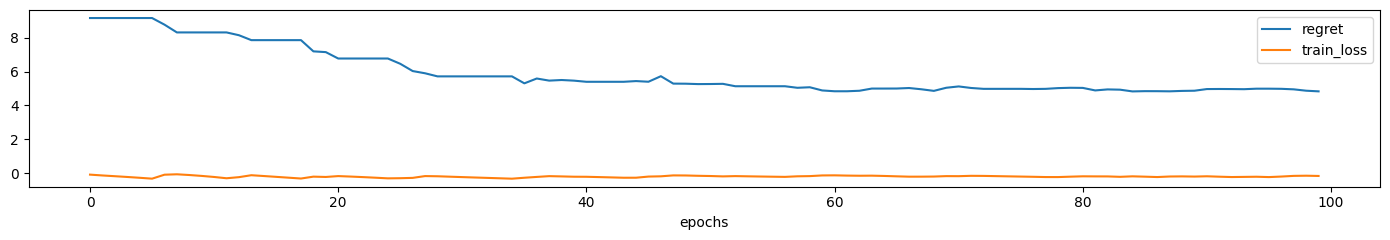

training time: 108.3270
R2: 0.710, MAE: 0.084, RMSE: 0.104 (training)
R2: 0.802, MAE: 0.063, RMSE: 0.079 (test)


In [4]:
bofis_nl = util.DFLModel(input_size=1, output_size=nitems, hidden_sizes=[16], problem=prb, name='bofis_2s', dfl_method='bofis_2s', dfl_params={'sigma': 0.1, 'sigma_multiplier': 1.1, 'max_iw_ratio': 8}, warm_start_state_dict=pfl_nl.state_dict(), lr=1e-4, drop_cache_at_end=False)
bofis_nl, history, metadata_bofis = util.train_ml_model(bofis_nl, data_tr.index.values.reshape(-1, 1), data_tr.values, epochs=100, load_cached=use_cached_weights, enable_progress_bar=False, accelerator='cpu', batch_size=32)
util.plot_training_history(history, metadata=metadata_bofis, figsize=figsize_narrow, print_scores=False)
util.print_ml_metrics(bofis_nl, data_tr.index.values.reshape(-1, 1), data_tr.values, label='training')
util.print_ml_metrics(bofis_nl, data_ts.index.values.reshape(-1, 1), data_ts.values, label='test')

## Basic IS Off-Policy Gradient

**In terms of EVPF, the results are comparable to the previous ones**

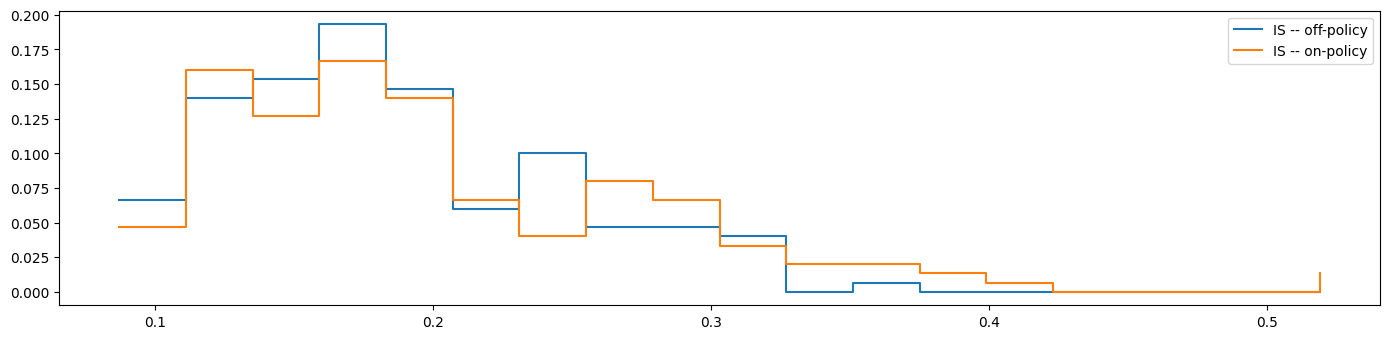

Mean: 0.186 (IS -- off-policy), 0.203 (IS -- on-policy)


In [5]:
bofis_nl_evpf = util.compute_evpf_2s(prb, bofis_nl, data_ts, tlim=10)
util.plot_histogram(bofis_nl_evpf, figsize=figsize, label='IS -- off-policy', data2=bonis_nl_evpf, label2='IS -- on-policy', print_mean=True);

## Basic IS Off-Policy Gradient

**But the number of computed solution is vastly different**

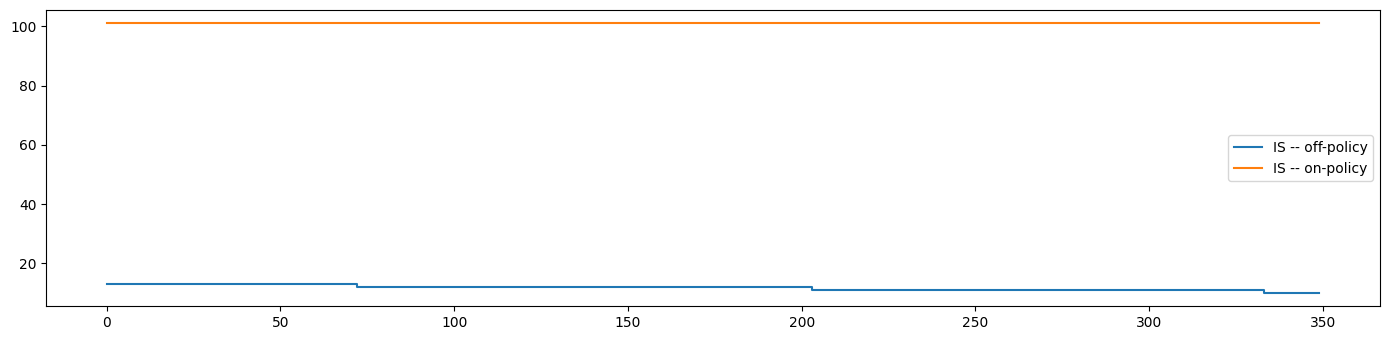

Total: 4108 (IS -- off-policy), 35350 (IS -- on-policy)


In [6]:
bofis_counts = list(metadata_bofis['solution count'].values())
bonis_counts = list(metadata_bonis['solution count'].values())
util.plot_solcount(bofis_counts, figsize=figsize, label='IS -- off-policy', counts2=bonis_counts, label2='IS -- on-policy', print_total=True);

* The plot shows the number of solved problems, by example, in decreasing order
* In a non-trivial problem, this would dominate the computational cost

## Some Final Remarks

**DFL is an example of how learning and optimization can be combined**

The two approaches have complementary strengths

* ML methods excel at dealing with uncertainty and non-linearities
* Optimizaiton methods can deal with constraints and search

With a combination, each approach can focus on what it does best

**For the best results, we need to be clever**

* The trick is thinking about the problem as a whole
* ...Then choosing how to split responsbilities between ML and optimization
* The goal is have two simple, integrated problems, instead of single, complex, one

**If you are curious, it's worth checking:**

* About these methods, the classical [RL book by Sutton & Barto](https://web.stanford.edu/class/psych209/Readings/SuttonBartoIPRLBook2ndEd.pdf) (especially ch. 5)
* About integrating RL and optimization, [this paper of ours can be a good start](https://cris.unibo.it/retrieve/handle/11585/988177/0ab499cb-8dda-4af5-bd76-017483e668ee/1-s2.0-S0950705124010177-main.pdf)